In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import torch
import os
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 1024
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))

In [ ]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps

import numpy as np
from collections import deque


def compute_wall_mask(maze):
    """
    maze: 2D np.array of shape (48,48), 1=corridor, 0=wall
    returns: same shape, dtype=uint8
    """
    return (maze == 1).astype(np.uint8)

def compute_distance_map(maze, start_goal):
    """
    maze: 2D array 1=corridor, 0=wall
    start_goal: 2D binary array, 1 at the two points, 0 elsewhere
    returns: 2D int array where each cell = shortest-path distance (in steps)
             to the nearest start/goal; walls get a large value or np.inf.
    """
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    q = deque()

    # initialize BFS frontier at both points
    for (i, j), val in np.ndenumerate(start_goal):
        if val == 1:
            dist[i, j] = 0
            q.append((i, j))

    # 4‐connected neighbors
    neighbors = [(1,0),(-1,0),(0,1),(0,-1)]

    while q:
        i, j = q.popleft()
        for di, dj in neighbors:
            ii, jj = i + di, j + dj
            if 0 <= ii < H and 0 <= jj < W:
                # only traverse corridors
                if maze[ii, jj] == 1 and dist[ii, jj] == np.inf:
                    dist[ii, jj] = dist[i, j] + 1
                    q.append((ii, jj))
    return dist

def map_distances(maze, start_goal, radius=2):
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    maze2 = maze.copy()
    q = deque()

    # seed from input blocks
    for (i,j), v in np.ndenumerate(start_goal):
        if v:
            dist[i,j] = 0
            maze2[i,j] = 1
            q.append((i,j))

    # all offsets in a (2*radius+1)^2 patch, excluding (0,0)
    nbrs = [(dx,dy)
            for dx in range(-radius, radius+1)
            for dy in range(-radius, radius+1)
            if not (dx==0 and dy==0)]

    while q:
        i, j = q.popleft()
        dnext = dist[i, j] + 1
        for dx, dy in nbrs:
            ii, jj = i + dx, j + dy
            if not (0 <= ii < H and 0 <= jj < W): 
                continue
            if maze2[ii, jj] != 1:
                continue

            # only block if both orthogonal neighbors are walls
            if dx != 0 and dy != 0:
                if maze2[i+dx, j] == 0 and maze2[i, j+dy] == 0:
                    continue

            if dist[ii, jj] == np.inf:
                dist[ii, jj] = dnext
                q.append((ii, jj))

    return dist

def bfs_distance(maze, seeds):
    H, W = maze.shape
    dist = np.full((H, W), np.inf, dtype=float)
    q = deque()

    # allow BFS to traverse the seeds even if maze[...] == 0
    maze2 = maze.copy()
    for (i, j) in seeds:
        dist[i, j] = 0
        maze2[i, j] = 1
        q.append((i, j))

    nbrs = [(1,0),(-1,0),(0,1),(0,-1)]
    while q:
        i, j = q.popleft()
        for di, dj in nbrs:
            ii, jj = i+di, j+dj
            if 0 <= ii < H and 0 <= jj < W:
                if maze2[ii, jj] == 1 and dist[ii, jj] == np.inf:
                    dist[ii, jj] = dist[i, j] + 1
                    q.append((ii, jj))
    return dist

def get_start_coordinates(maze, start_goal):
    H, W = maze.shape

    # 1) Flood-fill start_goal into two blocks
    visited = np.zeros_like(start_goal, bool)
    blocks = []
    for (i,j), v in np.ndenumerate(start_goal):
        if v and not visited[i,j]:
            comp, q = [], deque([(i,j)])
            visited[i,j] = True
            while q:
                x,y = q.popleft()
                comp.append((x,y))
                for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                    nx, ny = x+dx, y+dy
                    if (0<=nx<H and 0<=ny<W and start_goal[nx,ny]
                        and not visited[nx,ny]):
                        visited[nx,ny] = True
                        q.append((nx,ny))
            blocks.append(comp)
    
    return blocks

def compute_shortest_path_mask(maze, start_goal):
    """
    Returns an (H,W) uint8 mask marking corridor cells on any shortest path
    between the two 2×2 input blocks. If the blocks are disconnected, returns
    all zeros.
    """
    H, W = maze.shape

    blocks = get_start_coordinates(maze, start_goal)
    
    if len(blocks) != 2:
        raise ValueError("Expected exactly two disjoint 2×2 blocks in start_goal.")

    # 2) BFS distances from each block
    dist0 = bfs_distance(maze, blocks[0])
    dist1 = bfs_distance(maze, blocks[1])

    # 3) Minimal distance between blocks
    d_min = min(dist0[i,j] for (i,j) in blocks[1])

    # 4) If infinite, no path exists → return zero mask
    if np.isinf(d_min):
        return np.zeros((H, W), dtype=np.uint8)

    # 5) Mark cells where dist0 + dist1 == d_min and are corridors
    sp = ((dist0 + dist1) == d_min) & (maze == 1)
    return sp.astype(np.uint8)


def compute_reachable_mask(dist_map, t):
    """
    All cells reachable within t conv‐hops.
    """
    return (dist_map <= t).astype(np.uint8)

def compute_frontier_shell(dist_map, t):
    """
    Cells reached *exactly* on hop t.
    """
    return (dist_map == t).astype(np.uint8)

def compute_articulation_points(maze, start_goal):
    """
    Binary map of corridor‐cells whose removal disconnects the two input blocks.
    Brute‐force: for each corridor cell, zero it out and test connectivity.
    """
    H, W = maze.shape
    # find the two blocks again
    visited = np.zeros_like(start_goal, bool)
    blocks = []
    for (i,j), v in np.ndenumerate(start_goal):
        if v and not visited[i,j]:
            comp = []
            q = deque([(i,j)])
            visited[i,j] = True
            while q:
                x,y = q.popleft()
                comp.append((x,y))
                for dx,dy in [(1,0),(-1,0),(0,1),(0,-1)]:
                    nx, ny = x+dx, y+dy
                    if 0<=nx<H and 0<=ny<W and start_goal[nx,ny] and not visited[nx,ny]:
                        visited[nx,ny] = True
                        q.append((nx,ny))
            blocks.append(comp)
    assert len(blocks)==2

    def connected_without(rem_i, rem_j):
        """Test if block0 can reach block1 when (rem_i,rem_j) is treated as wall."""
        seen = np.zeros((H,W), bool)
        q = deque()
        # seed from block0, but skip if removing that cell
        for (i,j) in blocks[0]:
            if (i,j)!=(rem_i,rem_j):
                seen[i,j] = True
                q.append((i,j))
        while q:
            i,j = q.popleft()
            if (i,j) in blocks[1]:
                return True
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ii,jj = i+di, j+dj
                if 0<=ii<H and 0<=jj<W and not seen[ii,jj]:
                    if (ii,jj)==(rem_i,rem_j):
                        continue
                    if maze[ii,jj]==1 or start_goal[ii,jj]:
                        seen[ii,jj] = True
                        q.append((ii,jj))
        return False

    art_map = np.zeros((H,W), np.uint8)
    for (i,j), v in np.ndenumerate(maze):
        if v==1 and not start_goal[i,j]:
            if not connected_without(i,j):
                art_map[i,j] = 1
    return art_map

def compute_node_degree(maze):
    """
    For each corridor cell, count 4‐connected corridor neighbors.
    """
    H, W = maze.shape
    deg = np.zeros((H,W), int)
    for (i,j), v in np.ndenumerate(maze):
        if v==1:
            cnt = 0
            for di,dj in [(1,0),(-1,0),(0,1),(0,-1)]:
                ii, jj = i+di, j+dj
                if 0<=ii<H and 0<=jj<W and maze[ii,jj]==1:
                    cnt += 1
            deg[i,j] = cnt
    return deg

def bresenham_line(x0, y0, x1, y1):
    """
    Bresenham’s line algorithm between two integer points (x0,y0)->(x1,y1).
    Returns list of (x,y) coordinates on the line.
    """
    pts = []
    dx = abs(x1-x0)
    dy = abs(y1-y0)
    x, y = x0, y0
    sx = 1 if x1>x0 else -1
    sy = 1 if y1>y0 else -1
    if dx > dy:
        err = dx/2.0
        while x != x1:
            pts.append((x,y))
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
    else:
        err = dy/2.0
        while y != y1:
            pts.append((x,y))
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy
    pts.append((x1,y1))
    return pts

def compute_euclidean_los_mask(maze, start_goal):
    """
    Binary mask: for each corridor cell (i,j), 1 if there exists at least one
    straight (Bresenham) line to any input cell that passes only through
    corridors or input cells.
    """
    H, W = maze.shape
    los = np.zeros((H,W), np.uint8)
    # list all target coords
    targets = [(i,j) for (i,j),v in np.ndenumerate(start_goal) if v]
    for (i,j), v in np.ndenumerate(maze):
        if v != 1:
            continue
        for (ti,tj) in targets:
            line = bresenham_line(i,j, ti,tj)
            if all(maze[x,y]==1 or start_goal[x,y]==1 for (x,y) in line):
                los[i,j] = 1
                break
    return los

def both_reachable_mask(maze, start_goal, t):
    """
    Return a mask where cells are True iff reachable within ≤ t steps
    from both start1 and start2 using the existing reachable_mask.
    """
    start_coordinates = get_start_coordinates(maze, start_goal)
    
    start1 = np.zeros_like(start_goal)
    for row, col in start_coordinates[0]:
        start1[row,col] = 1

    start2 = np.zeros_like(start_goal)
    try:
        for row, col in start_coordinates[1]:
            start2[row,col] = 1
    except:
        for row, col in start_coordinates[0]:
            start2[row,col] = 1

    dist_map = map_distances(maze, start1)
    reach_start1 = compute_reachable_mask(dist_map, t=t)

    dist_map = map_distances(maze, start2)
    reach_start2 = compute_reachable_mask(dist_map, t=t)

    return reach_start1 & reach_start2

In [ ]:
# ——— User‐set paths & names ———
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    # also used as epoch

# ReLU
wandb_name = "earnest-planet-436"
checkpoint = 800

# ReLU, I->I recurrence, Center-Excitation
# wandb_name = "young-totem-460"
# checkpoint = 480

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)
model.to(device)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
try:
    state_dict = state_dict["model_state"]
except:
    pass

model.load_state_dict(prepare_rnn_weights(state_dict))

In [ ]:
excitatory = True
num_steps = 20

num_samples = len(test_loader.dataset) if hasattr(test_loader, 'dataset') else sum(1 for _ in test_loader)
activations = np.zeros((num_samples, num_steps, 8, 48, 48), dtype=np.float32)

sample_idx = 0
for batch_inputs, label in tqdm(test_loader):
    # input: (batch_size, channels, H, W)
    batch_size = batch_inputs.shape[0]
    batch_inputs = batch_inputs.to(device)
    _, batch_neuron_states, _ = model(batch_inputs, num_steps=num_steps)
    activity = model.query_neuron_states(batch_neuron_states, 0, 0 if excitatory else 1).detach().cpu().numpy()
    activations[sample_idx:sample_idx+batch_size, :, :, :, :] = activity
    sample_idx += batch_size

In [ ]:
# dist_matrix = np.load("feature_maps/dist_matrix.npy")
# frontier_matrix = np.load("feature_maps/frontier_matrix.npy")
# reachable_matrix = np.load("feature_maps/reachable_matrix.npy")
both_reachable_matrix = np.load("feature_maps/both_reachable_matrix.npy")

In [ ]:
# ============================ InfoNCE end-to-end ============================
# Requirements: torch, numpy, tqdm
# - Small MLP encoders on flattened A and B
# - Fixed tau InfoNCE (lower bound = log(batch) - loss)
# - Validation + shuffle-null eval each epoch (prints ΔLB)
# - Notebook-safe DataLoaders (num_workers=0)
# - Cosine LR with warmup, grad clipping, optional grad accumulation

import math, numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

# ---------------------- Data ----------------------
class PairDataset(Dataset):
    def __init__(self, A: np.ndarray, B: np.ndarray, dtype=torch.float32):
        assert A.shape[0] == B.shape[0], "A and B must have same #samples"
        self.A = torch.from_numpy(np.ascontiguousarray(A)).to(dtype)
        self.B = torch.from_numpy(np.ascontiguousarray(B)).to(dtype)
    def __len__(self): return self.A.shape[0]
    def __getitem__(self, i): return self.A[i], self.B[i]

def make_loaders(A, B, batch_size=1024, val_frac=0.1, seed=0):
    N = A.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(N)
    n_val = max(1, int(N * val_frac))
    val_idx, train_idx = idx[:n_val], idx[n_val:]
    ds_train = PairDataset(A[train_idx], B[train_idx])
    ds_val   = PairDataset(A[val_idx],   B[val_idx])
    # Notebook-safe: num_workers=0, pin_memory=False
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True,
                          drop_last=True,  num_workers=0, pin_memory=False)
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False,
                          drop_last=False, num_workers=0, pin_memory=False)
    return dl_train, dl_val

# ---------------------- Encoders ----------------------
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim=128, hidden=(512,256), dropout=0.0):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            if dropout > 0: layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, out_dim), nn.LayerNorm(out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def l2_normalize(x, eps=1e-8): return x / (x.norm(dim=1, keepdim=True) + eps)

# ---------------------- Loss (fixed tau) ----------------------
class InfoNCELoss(nn.Module):
    def __init__(self, tau=0.1, symmetric=True):
        super().__init__()
        self.tau = float(tau)
        self.symmetric = symmetric
    def forward(self, zA, zB):
        zA = l2_normalize(zA); zB = l2_normalize(zB)
        logits = (zA @ zB.T) / self.tau
        B = zA.size(0)
        labels = torch.arange(B, device=zA.device)
        ce_ab = F.cross_entropy(logits, labels)
        if self.symmetric:
            ce_ba = F.cross_entropy(logits.T, labels)
            loss = 0.5 * (ce_ab + ce_ba)
        else:
            loss = ce_ab
        mi_lb = math.log(B) - float(loss.detach().item())
        return loss, mi_lb

# ---------------------- Eval (real + null) ----------------------
@torch.no_grad()
def eval_infonce(encoderA, encoderB, loader, loss_obj, device="cuda", shuffle_null=False, topk=(1,5)):
    encoderA.eval(); encoderB.eval()
    tot_lb, tot_n = 0.0, 0
    correct_topk = {k:0 for k in topk}
    align_sum, align_cnt = 0.0, 0
    zsA, zsB = [], []

    for A, B in loader:
        A = A.to(device); B = B.to(device)
        zA = encoderA(A); zB = encoderB(B)
        if shuffle_null:
            perm = torch.randperm(zB.size(0), device=zB.device)
            zB = zB[perm]
        loss, mi_lb = loss_obj(zA, zB)
        bs = A.size(0); tot_lb += mi_lb * bs; tot_n += bs

        zA = l2_normalize(zA); zB = l2_normalize(zB)
        logits = (zA @ zB.T) / loss_obj.tau
        labels = torch.arange(bs, device=A.device)
        ranks = logits.argsort(dim=1, descending=True)
        for k in topk:
            correct_topk[k] += (ranks[:, :k] == labels[:, None]).any(dim=1).sum().item()
        align_sum += torch.mean((zA - zB).pow(2)).item() * bs
        align_cnt += bs

        if len(zsA) < 10_000:
            zsA.append(zA.detach().cpu()); zsB.append(zB.detach().cpu())

    val_lb = tot_lb / max(1, tot_n)
    topk_acc = {k: correct_topk[k]/max(1, tot_n) for k in topk}
    # Uniformity proxy via singular values (collapse if near 0 spread)
    Z = torch.cat(zsA + zsB, dim=0).numpy()
    svals = np.linalg.svd(Z - Z.mean(0, keepdims=True), compute_uv=False)
    sval_spread = float(np.std(svals) / (np.mean(svals)+1e-12))
    alignment = align_sum / max(1, align_cnt)
    return dict(val_lb_nats=val_lb, topk=topk_acc, alignment=alignment, sval_spread=sval_spread)

# ---------------------- Training ----------------------
def train_infonce(
    A, B,
    embed_dim=128,
    hiddenA=(512,256), hiddenB=(512,256),
    tau=0.1, symmetric=True,
    batch_size=1024, epochs=12,
    lr=3e-4, weight_decay=1e-4,
    val_frac=0.1, seed=0, device=None,
    fp16=True, grad_clip=1.0,
    accum_steps=1,                # >1 = gradient accumulation (bigger effective batch)
    early_stop_patience=5,
    print_progress=True
):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed); np.random.seed(seed)
    dl_train, dl_val = make_loaders(A, B, batch_size=batch_size, val_frac=val_frac, seed=seed)
    dA, dB = A.shape[1], B.shape[1]
    encA = MLP(dA, embed_dim, hiddenA).to(device)
    encB = MLP(dB, embed_dim, hiddenB).to(device)
    loss_obj = InfoNCELoss(tau=tau, symmetric=symmetric).to(device)

    params = list(encA.parameters()) + list(encB.parameters())
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    total_steps = epochs * len(dl_train)
    warmup = max(100, int(0.03 * total_steps))
    cosine = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1, total_steps - warmup))
    scaler = torch.amp.GradScaler(device="cuda", enabled=(fp16 and device.startswith("cuda")))

    best_val, best_state, patience = -1e9, None, early_stop_patience
    step = 0
    for epoch in range(1, epochs+1):
        encA.train(); encB.train()
        running_lb, n_seen = 0.0, 0
        if print_progress:
            pbar = tqdm(dl_train, desc=f"Epoch {epoch}/{epochs}")
        else:
            pbar = dl_train

        opt.zero_grad(set_to_none=True)
        for it, (A_batch, B_batch) in enumerate(pbar, start=1):
            A_batch = A_batch.to(device, non_blocking=False)
            B_batch = B_batch.to(device, non_blocking=False)
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(fp16 and device.startswith("cuda"))):
                loss, mi_lb = loss_obj(encA(A_batch), encB(B_batch))
                loss_to_backprop = loss / max(1, accum_steps)
            scaler.scale(loss_to_backprop).backward()

            if it % accum_steps == 0:
                if grad_clip is not None:
                    scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(params, grad_clip)
                scaler.step(opt); scaler.update()
                opt.zero_grad(set_to_none=True)

                step += 1
                # warmup then cosine
                if step <= warmup:
                    for g in opt.param_groups:
                        g["lr"] = lr * step / max(1, warmup)
                else:
                    cosine.step()

            bs = A_batch.size(0)
            running_lb += mi_lb * bs; n_seen += bs
            if print_progress: pbar.set_postfix(train_lb=f"{running_lb/n_seen:.3f}")

        # ----- Validation (real + shuffle-null) -----
        real = eval_infonce(encA, encB, dl_val, loss_obj, device=device, shuffle_null=False)
        null = eval_infonce(encA, encB, dl_val, loss_obj, device=device, shuffle_null=True)
        delta = real["val_lb_nats"] - null["val_lb_nats"]
        print(f"[VAL]  LB={real['val_lb_nats']:.3f}  ΔLB={delta:.3f}  top1={real['topk'][1]:.3f}  "
              f"align={real['alignment']:.3f}  sval_spread={real['sval_spread']:.3f}")
        print(f"[NULL] LB={null['val_lb_nats']:.3f}  top1={null['topk'][1]:.3f}")

        # early stopping on ΔLB (more robust than raw LB)
        if delta > best_val + 1e-4:
            best_val, patience = delta, early_stop_patience
            best_state = dict(encA=encA.state_dict(), encB=encB.state_dict())
        else:
            patience -= 1
            if patience == 0:
                print("Early stopping.")
                break

    if best_state:
        encA.load_state_dict(best_state["encA"])
        encB.load_state_dict(best_state["encB"])
    return encA, encB, {"best_delta_lb": best_val}

# ---------------------- (Optional) synthetic quick test ----------------------
def gen_latent_share(N, dZ=16, dA=256, dB=256, sA=1.0, sB=1.0, noiseA=0.5, noiseB=0.5, seed=0):
    rng = np.random.default_rng(seed)
    U = rng.standard_normal((dA, dZ)) / np.sqrt(dZ)
    V = rng.standard_normal((dB, dZ)) / np.sqrt(dZ)
    z = rng.standard_normal((N, dZ))
    A = np.tanh(z @ U.T) * sA + noiseA * rng.standard_normal((N, dA))
    B = np.maximum(z @ V.T, 0.0) * sB + noiseB * rng.standard_normal((N, dB))
    return A.astype("float32"), B.astype("float32")


In [ ]:
num_channels = activations.shape[2]
num_neurons = activations.shape[3]
mi_vectors = np.zeros(num_channels) #ii

num_samples = 10000

steps_start = 0
total_num_steps = num_steps - steps_start

A = both_reachable_matrix[:num_samples, steps_start:num_steps].reshape(num_samples*total_num_steps, -1)
B = activations[:num_samples, steps_start:num_steps].reshape(num_samples*total_num_steps, num_channels, -1)

for channel_idx in range(num_channels):
    encA, encB, stats = train_infonce(
        A, B[:, channel_idx],
        embed_dim=128,
        hiddenA=(1024, 512),
        hiddenB=(1024, 512),
        tau=0.1, symmetric=True,
        batch_size=4096, epochs=20,
        lr=1e-4, weight_decay=1e-4,
        val_frac=0.1, seed=2, device="cuda" if torch.cuda.is_available() else "cpu",
        fp16=True, grad_clip=1.0,
        accum_steps=1,            # increase to emulate bigger batches
        early_stop_patience=5,
    )
    print("Best ΔLB (nats):", stats["best_delta_lb"])
    mi_vectors[channel_idx] = stats["best_delta_lb"]

Text(0, 0.5, 'MI')

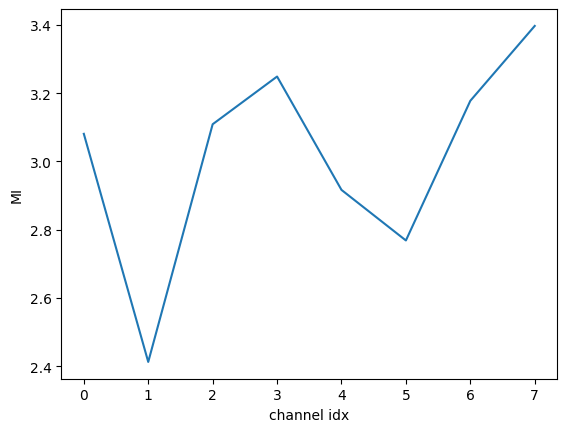

In [10]:
plt.plot(mi_vectors)
plt.xlabel("channel idx")
plt.ylabel("MI")

In [ ]:
num_channels = activations.shape[2]
num_steps = activations.shape[1]
num_neurons = activations.shape[3]
mi_vectors = np.zeros((num_channels, num_steps))
analysis_steps = [2, 3, 4, 5, 6, 9, 12, 15, 18, 19, 21, 23, 25, 27, 29]

for step_idx in analysis_steps:
    for channel_idx in range(num_channels):
        A = both_reachable_matrix[:num_samples, step_idx]
        B = activations[:A.shape[0], step_idx, channel_idx]
        encA, encB, stats = train_infonce(
            A, B,
            embed_dim=128,
            hiddenA=(1024, 512),
            hiddenB=(1024, 512),
            tau=0.1, symmetric=True,
            batch_size=4096, epochs=15,
            lr=3e-4, weight_decay=1e-4,
            val_frac=0.1, seed=2, device="cuda" if torch.cuda.is_available() else "cpu",
            fp16=True, grad_clip=1.0,
            accum_steps=1,            # increase to emulate bigger batches
            early_stop_patience=5,
            plot_progress=False
        )
        print("Best ΔLB (nats):", stats["best_delta_lb"])
        mi_vectors[channel_idx, step_idx] = stats["best_delta_lb"]

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(10, 6))
try:
    from matplotlib import colormaps
    colors = colormaps['tab10'].colors
except (ImportError, AttributeError, KeyError):
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for channel_idx in range(num_channels):
    mi_vector = np.clip(mi_vectors[channel_idx, :], 0, None)  # shape: (num_steps, num_neurons)
    # Only use analysis_steps
    mi_vector_steps = mi_vector[analysis_steps]  # shape: (len(analysis_steps), num_neurons)
    mi = mi_vector_steps 
    std_mi = mi_vector_steps
    color = colors[channel_idx % len(colors)]
    label = f'Channel {channel_idx}' 
    plt.plot(analysis_steps, mi, color=color, label=label)
plt.xlabel('Analysis Step')
plt.ylabel('Mean MI')
plt.title('Mean Mutual Information')
plt.legend()
plt.tight_layout()
plt.show()